testing stuff :0

In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import libpysal
from libpysal.weights import KNN, lag_spatial
from esda.moran import Moran

In [12]:
# combine all high school districts to one file
path_sec = "/home/ben/gds_data/502_project2/MontanaSchoolDistricts_shp/MontanaSchoolDistricts_shp/Secondary.shp"
path_uni = "/home/ben/gds_data/502_project2/MontanaSchoolDistricts_shp/MontanaSchoolDistricts_shp/Unified.shp"

gdf_sec = gpd.read_file(path_sec)
gdf_uni = gpd.read_file(path_uni)
gdf_districts = pd.concat([gdf_sec, gdf_uni], ignore_index=True)

target_crs = "EPSG:32100"
if gdf_districts.crs != target_crs:
    gdf_districts = gdf_districts.to_crs(target_crs)

df_schools = pd.read_csv("public_highschools_clean.csv")

gdf_schools = gpd.GeoDataFrame(
    df_schools,
    geometry=gpd.points_from_xy(df_schools.longitude, df_schools.latitude),
    crs="EPSG:4326"
    )

gdf_schools = gdf_schools.to_crs("EPSG:32100")

# remove nans and infs from the pct_change_20yr column
gdf_schools = gdf_schools.replace([np.inf, -np.inf], np.nan)
gdf_schools = gdf_schools.dropna(subset=['pct_change_20yr', 'geometry']).reset_index(drop=True)


w_knn5 = KNN.from_dataframe(gdf_schools, k=5)
w_knn5.transform = 'R'

# compute spatial lag
gdf_schools['lag_pct_change'] = lag_spatial(w_knn5, gdf_schools['pct_change_20yr'])

# morans i
moran = Moran(gdf_schools['pct_change_20yr'], w_knn5)

# standardize
y_raw = gdf_schools['pct_change_20yr']
y_std = (y_raw - y_raw.mean()) / y_raw.std()
lag_std = lag_spatial(w_knn5, y_std)


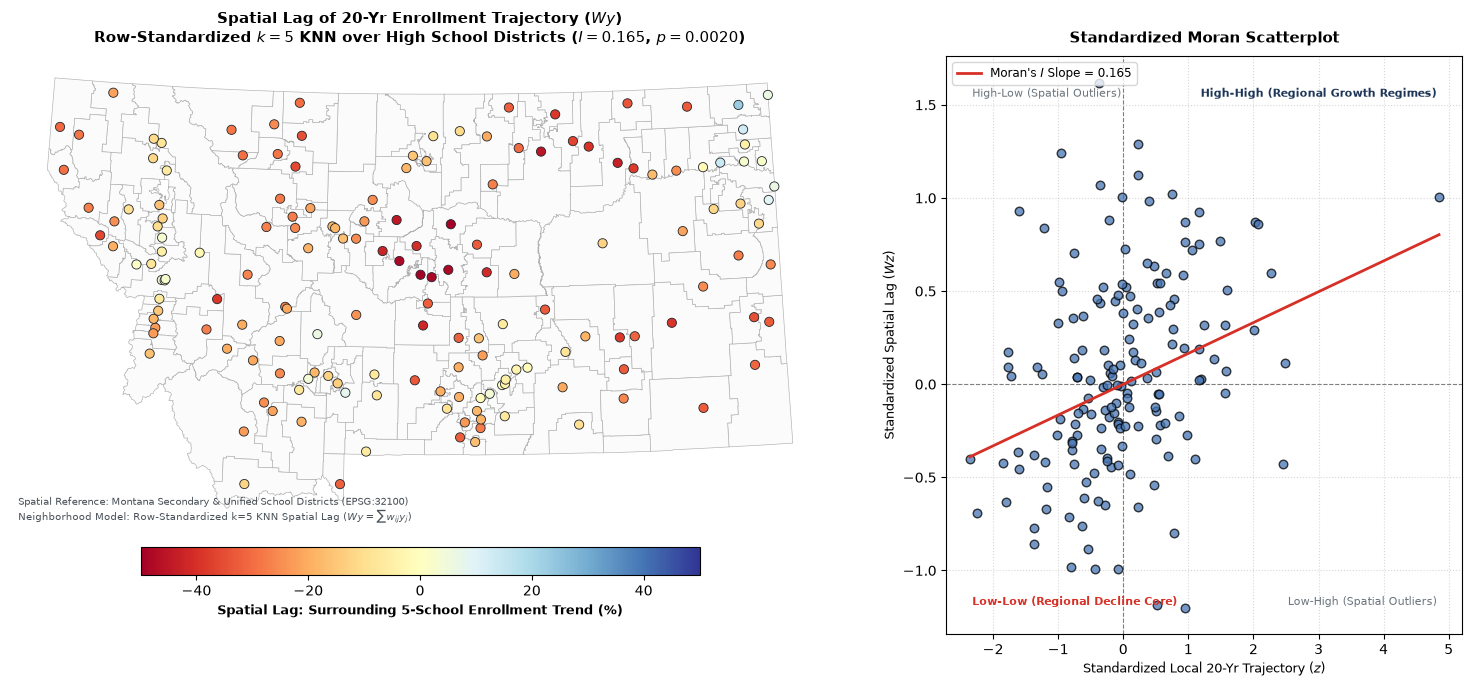

In [13]:
# plot time!
fig = plt.figure(figsize=(19, 7.5))
gs = fig.add_gridspec(1, 2, width_ratios=[1.25, 0.75], wspace=0.14)

ax_map = fig.add_subplot(gs[0])
ax_moran = fig.add_subplot(gs[1])

# PANEL A: SPATIAL LAG THEMATIC MAP
gdf_districts.plot(ax=ax_map, color='#fbfbfb', edgecolor='#b0b0b0', linewidth=0.45, zorder=1)

norm = mcolors.TwoSlopeNorm(vmin=-50, vcenter=0, vmax=50)
sc = ax_map.scatter(
    gdf_schools.geometry.x, gdf_schools.geometry.y,
    c=gdf_schools['lag_pct_change'], 
    cmap='RdYlBu', 
    norm=norm,
    s=44, 
    edgecolor='#212529', 
    linewidth=0.6, 
    zorder=3
)

ax_map.set_title(
    f"Spatial Lag of 20-Yr Enrollment Trajectory ($Wy$)\n"
    f"Row-Standardized $k=5$ KNN over High School Districts ($I = {moran.I:.3f}$, $p = {moran.p_sim:.4f}$)",
    fontsize=11, fontweight='bold', pad=10
)
ax_map.axis('off')

ax_map.text(
    0.01, 0.02, 
    "Spatial Reference: Montana Secondary & Unified School Districts (EPSG:32100)\n"
    "Neighborhood Model: Row-Standardized k=5 KNN Spatial Lag ($Wy = \\sum w_{ij} y_j$)",
    transform=ax_map.transAxes, fontsize=7.5, color='#495057'
)

cbar = fig.colorbar(sc, ax=ax_map, orientation='horizontal', shrink=0.65, pad=0.03)
cbar.set_label("Spatial Lag: Surrounding 5-School Enrollment Trend (%)", fontsize=9, fontweight='bold')

# PANEL B: MORAN SCATTERPLOT
ax_moran.scatter(y_std, lag_std, color='#4575b4', edgecolor='black', alpha=0.75, s=38, zorder=3)

# Draw the theoretical Moran's I slope line (y = I * x)
x_vals = np.linspace(y_std.min(), y_std.max(), 100)
ax_moran.plot(
    x_vals, moran.I * x_vals, 
    color='#d73027', 
    linewidth=2.0, 
    label=f"Moran's $I$ Slope = {moran.I:.3f}", 
    zorder=4
)

ax_moran.axhline(0, color='grey', linestyle='--', linewidth=0.8)
ax_moran.axvline(0, color='grey', linestyle='--', linewidth=0.8)

# Quadrant labels
ax_moran.text(0.95, 0.05, "Low-High (Spatial Outliers)", transform=ax_moran.transAxes, ha='right', fontsize=8, color='#6c757d')
ax_moran.text(0.05, 0.05, "Low-Low (Regional Decline Core)", transform=ax_moran.transAxes, fontsize=8, color='#d73027', fontweight='bold')
ax_moran.text(0.95, 0.93, "High-High (Regional Growth Regimes)", transform=ax_moran.transAxes, ha='right', fontsize=8, color='#1d3557', fontweight='bold')
ax_moran.text(0.05, 0.93, "High-Low (Spatial Outliers)", transform=ax_moran.transAxes, fontsize=8, color='#6c757d')

ax_moran.set_title("Standardized Moran Scatterplot", fontsize=11, fontweight='bold', pad=10)
ax_moran.set_xlabel("Standardized Local 20-Yr Trajectory ($z$)", fontsize=9)
ax_moran.set_ylabel("Standardized Spatial Lag ($Wz$)", fontsize=9)
ax_moran.grid(True, linestyle=':', alpha=0.5)
ax_moran.legend(frameon=True, fontsize=8.5, loc='upper left')

plt.tight_layout()
plt.savefig("view3_python_spatial_lag_fixed.png", dpi=300)
plt.show()